<a href="https://colab.research.google.com/github/opinner/thesis_introductory_figures/blob/main/Group_velocity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import matplotlib.pyplot as plt
import numpy as np


ONE_COLUMN_WIDTH = 8.3
TWO_COLUMN_WIDTH = 12
GOLDEN_RATIO = 1.61
CM = 1 / 2.54  # centimeters in inches
plt.rcParams.update({
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 9
})

In [4]:
def vertical_group_velocity(omega, f, N, k_horizontal):
    c = (omega**2 - f**2)**(3/2) * (N**2-omega**2)**(1/2) / (omega*(N**2-f**2)) / k_horizontal
    return c

def horizontal_group_velocity(omega, f, N, k_horizontal):
    c = (N**2-omega**2) * (omega**2-f**2) / (omega*(N**2-f**2)) / k_horizontal
    return c

def Olbers2012():
    N = 5e-3 # rad/s
    f = 0.727e-4 # at 30° S
    return N, f

def Weddell_Sea():
    N = 0.3e-3 # rad/s
    f = 1.3e-4 # rad/s at 64° S
    return N, f

/tmp/ipython-input-3671937487.py:21: RuntimeWarning: divide by zero encountered in divide
  travel_time_1km = one_km / vertical_group_velocity(omega, f, N, k)


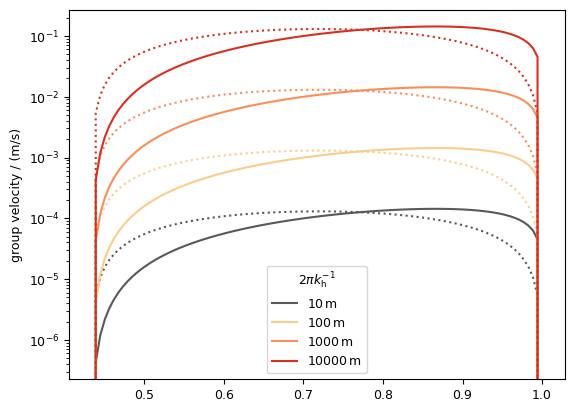

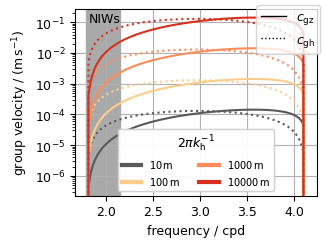

In [52]:
#N, f = Olbers2012()
N, f = Weddell_Sea()

fig, ax = plt.subplots(1)
fig2, ax2 = plt.subplots(1, figsize = (8*CM,6*CM), layout="constrained")
# ax2.axhline(10,color="k", alpha=0.8, ls=":")
# ax2.text(10.1, 9, s="10 days", ha="left", va="top", alpha=0.8)
# ax2.axhline(20,color="k", alpha=0.8, ls=":")
# ax2.text(9.9, 21, s="20 days", ha="right", va="bottom",alpha=0.8)

# ax2.semilogy([], [], label=f"$c_\\mathrm{{gz}}$", color="k")
# ax2.semilogy([], [], label=f"$c_\\mathrm{{gh}}$", ls=":", color="k")

omega = np.linspace(f,N,100)
for m, color in zip([1e1,1e2,1e3,1e4], ["0.35","#fdcc8a", "#fc8d59", "#d7301f"]):
    k = 2*np.pi / m
    ax.semilogy(omega/N, vertical_group_velocity(omega, f, N, k), label=f"{m:.0f}$\\,$m", color=color)
    ax.semilogy(omega/N, horizontal_group_velocity(omega, f, N, k), ls=":", color=color)

    one_km = 1000
    travel_time_1km = one_km / vertical_group_velocity(omega, f, N, k)
    travel_time_1km_in_days = travel_time_1km / 86400

    cpd = omega / (2*np.pi) *86400
    #ax2.semilogy(cpd, travel_time_1km_in_days, label=f"{m:.0f}$\\,$m")
    ax2.semilogy(cpd, vertical_group_velocity(omega, f, N, k), label=f"{m:.0f}$\\,$m", color=color)
    ax2.semilogy(cpd, horizontal_group_velocity(omega, f, N, k), ls=":", color=color)


f_cpd = f / (2*np.pi) *86400
# ax.axvspan(f_cpd, 1.2*f_cpd, color='0.95')

ax.set_ylabel("group velocity / (m/s)")
ax.legend(title= r"$2\pi k_\text{h}^{-1}$")

ax2.axvspan(f_cpd, 1.2*f_cpd, color='darkgray')
ax2.set_ylabel("travel time for $1000\\,$m in days")
ax2.set_ylabel("group velocity / (m$\\,$s$^{-1}$)")
ax2.set_xlabel("frequency / cpd")
ax2.grid(True)
ax2.text(1.98,1e-1,s="NIWs", ha="center")

# get the legend object
leg = ax2.legend(title= r"$2\pi k_\text{h}^{-1}$",ncols=2, fontsize=7, loc="best")
# change the line width for the legend
for line in leg.get_lines():
  line.set_linewidth(3)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color="k", lw=1, label=r"$c_\mathrm{gz}$"),
    Line2D([0], [0], color="k", lw=1, ls=":", label=r"$c_\mathrm{gh}$"),
]
leg2 = fig2.legend(handles=legend_handles, loc="upper right")

ax2.add_artist(leg)
#ax2.add_artist(leg2)

fig2.savefig("group_velocity.svg")
plt.show()